In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [2]:
DATA_DIR = Path("../Data")
LOG_RETURNS_FILE = DATA_DIR / "crypto_and_crix_log_returns.csv"
EVENT_DATES_FILE = DATA_DIR / "event_dates.csv"
ASSET_TICKER = "ETH"
MARKET_INDEX_TICKER = "CRIX"

EVENT_MARKET_MODEL_RESULTS_FILE = DATA_DIR / "event_market_model_results_scholes_williams.csv"
PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE = DATA_DIR / "pre_event_abnormal_log_returns_scholes_williams.csv"
ETH_EVENT_WINDOW_LOG_RETURNS_FILE = DATA_DIR / "eth_event_window_log_returns.csv"
CRIX_EVENT_WINDOW_LOG_RETURNS_FILE = DATA_DIR / "crix_event_window_log_returns.csv"
ETH_ABNORMAL_LOG_RETURNS_FILE = DATA_DIR / "eth_abnormal_log_returns_scholes_williams.csv"

ESTIMATION_WINDOW_START = 37
ESTIMATION_WINDOW_END = 7

EVENT_WINDOW_BEFORE = 3
EVENT_WINDOW_AFTER = 21

Z_SCORE = 1.96

In [3]:
log_returns = pd.read_csv(
    LOG_RETURNS_FILE,
    index_col="Date",
    parse_dates=["Date"],
).sort_index()

log_returns.head()

,BTC,ETH,XRP,LTC,BCH,ZEC,BSV,DASH,XMR,CRIX
Date,,,,,,,,,,
2017-09-08,-0.022803,-0.036021,0.018019,-0.036837,-0.020231,-0.037624,0.0,-0.006283,0.014305,-0.014211
2017-09-09,-0.041201,-0.056461,-0.069312,-0.079201,-0.085411,-0.073408,0.0,-0.047761,-0.047126,-0.026125
2017-09-10,-0.024092,-0.028771,-0.034067,-0.057211,-0.054591,-0.024823,0.0,-0.032413,-0.041688,0.009530
2017-09-11,0.003545,0.010540,0.057708,0.012930,0.003663,0.007992,0.0,0.017270,0.009435,-0.015231
2017-09-12,0.007521,0.018426,0.018519,0.012851,-0.011267,0.006524,0.0,0.010638,0.007646,-0.054887


In [4]:
required_columns = [ASSET_TICKER, MARKET_INDEX_TICKER]

missing_columns = [
    column
    for column in required_columns
    if column not in log_returns.columns
]

if missing_columns:
    raise KeyError(
        f"Missing columns: {missing_columns}. "
        f"Available columns: {log_returns.columns.tolist()}"
    )

eth_crix_log_returns = (
    log_returns[required_columns]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .sort_index()
)

eth_crix_log_returns.head()

,ETH,CRIX
Date,,
2017-09-08,-0.036021,-0.014211
2017-09-09,-0.056461,-0.026125
2017-09-10,-0.028771,0.009530
2017-09-11,0.010540,-0.015231
2017-09-12,0.018426,-0.054887


In [5]:
print("Columns:")
print(eth_crix_log_returns.columns.tolist())

print("\nDate range:")
print(f"Start: {eth_crix_log_returns.index.min().date()}")
print(f"End:   {eth_crix_log_returns.index.max().date()}")

print("\nShape:")
print(eth_crix_log_returns.shape)

print("\nMissing values:")
print(eth_crix_log_returns.isna().sum())

Columns:
['ETH', 'CRIX']

Date range:
Start: 2017-09-08
End:   2024-04-07

Shape:
(2404, 2)

Missing values:
ETH     0
CRIX    0
dtype: int64


In [6]:
event_dates_df = pd.read_csv(
    EVENT_DATES_FILE,
    parse_dates=["event_date"],
)

if "event_date" not in event_dates_df.columns:
    raise KeyError("event_dates.csv must contain an 'event_date' column.")

EVENT_DATES = pd.DatetimeIndex(event_dates_df["event_date"]).normalize()

print(f"Number of events: {len(EVENT_DATES)}")
print("\nEvent dates:")
EVENT_DATES

Number of events: 15

Event dates:


DatetimeIndex(['2017-10-16', '2019-02-28', '2019-12-08', '2020-01-02',
               '2020-10-14', '2020-12-01', '2021-04-15', '2021-08-05',
               '2021-10-27', '2021-12-09', '2022-06-30', '2022-09-06',
               '2022-09-15', '2023-04-12', '2024-03-13'],
              dtype='datetime64[ns]', name='event_date', freq=None)

In [7]:
event_date_check = pd.DataFrame(
    {
        "event_date": EVENT_DATES,
        "exists_in_data": EVENT_DATES.isin(eth_crix_log_returns.index),
    }
)

event_date_check

,event_date,exists_in_data
0,2017-10-16,True
1,2019-02-28,True
2,2019-12-08,True
3,2020-01-02,True
4,2020-10-14,True
5,2020-12-01,True
6,2021-04-15,True
7,2021-08-05,True
8,2021-10-27,True
9,2021-12-09,True


In [8]:
def estimate_event_market_models_scholes_williams(
    return_data,
    event_dates,
    days_before_start=37,
    days_before_end=7,
    asset_column="ETH",
    market_column="CRIX",
):
    """
    For each event date, fit the Scholes-Williams market model:
    
    ETH_t = alpha + beta_avg*CRIX_t + epsilon_t
    
    Where beta_avg = (beta_lagged + beta_current + beta_leading) / 3
    
    The full model with all three market return terms:
    ETH_t = alpha + beta_1*CRIX_{t-1} + beta_2*CRIX_t + beta_3*CRIX_{t+1} + epsilon_t
    
    Then: beta_avg = (beta_1 + beta_2 + beta_3) / 3
    
    This adjusts for non-synchronous trading between assets.
    
    Returns
    -------
    event_market_model_results : pd.DataFrame
        Event-level regression estimates and diagnostics.
        
    pre_event_abnormal_log_returns : pd.DataFrame
        Pre-event abnormal returns, one column per event.
    """
    return_data = return_data.copy()

    return_data.index = pd.to_datetime(return_data.index)
    return_data = return_data.sort_index()

    event_dates = pd.DatetimeIndex(pd.to_datetime(event_dates))

    result_records = []
    pre_event_ar_dict = {}

    for event_date in event_dates:
        window_start = event_date - pd.Timedelta(days=days_before_start)
        window_end = event_date - pd.Timedelta(days=days_before_end)

        estimation_window = return_data.loc[
            window_start:window_end,
            [asset_column, market_column],
        ].copy()

        estimation_window = (
            estimation_window
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        if len(estimation_window) < 10:
            print(
                f"Skipping {event_date.date()}: "
                "insufficient data in estimation window."
            )
            result_records.append(
                {
                    "event_date": event_date,
                    "alpha": np.nan,
                    "beta_avg": np.nan,
                    "beta_lagged": np.nan,
                    "beta_current": np.nan,
                    "beta_leading": np.nan,
                    "r_squared": np.nan,
                    "residual_std_error": np.nan,
                }
            )
            continue

        # Extract returns
        asset_returns = estimation_window[asset_column].values
        market_returns = estimation_window[market_column].values

        # Create lagged, current, and leading market returns
        market_current = market_returns.reshape(-1, 1)
        market_lagged = np.roll(market_returns, 1).reshape(-1, 1)
        market_leading = np.roll(market_returns, -1).reshape(-1, 1)

        # Set first lagged value and last leading value to NaN
        market_lagged[0] = np.nan
        market_leading[-1] = np.nan

        # Create design matrix with all three market return terms
        X = np.hstack([market_current, market_lagged, market_leading])
        X = sm.add_constant(X, has_constant='add')

        # Remove rows with NaN values
        valid_idx = ~np.isnan(X).any(axis=1)
        X = X[valid_idx]
        y = asset_returns[valid_idx].reshape(-1, 1)

        if len(y) < 5:
            print(
                f"Skipping {event_date.date()}: "
                "insufficient valid data after creating lags."
            )
            result_records.append(
                {
                    "event_date": event_date,
                    "alpha": np.nan,
                    "beta_avg": np.nan,
                    "beta_lagged": np.nan,
                    "beta_current": np.nan,
                    "beta_leading": np.nan,
                    "r_squared": np.nan,
                    "residual_std_error": np.nan,
                }
            )
            continue

        # Fit the model
        model = sm.OLS(y, X)
        results = model.fit()

        # Extract coefficients
        alpha = results.params[0]
        beta_current = results.params[1]
        beta_lagged = results.params[2]
        beta_leading = results.params[3]

        # Calculate average beta (Scholes-Williams)
        beta_avg = (beta_lagged + beta_current + beta_leading) / 3

        # Store results
        result_records.append(
            {
                "event_date": event_date,
                "alpha": alpha,
                "beta_avg": beta_avg,
                "beta_lagged": beta_lagged,
                "beta_current": beta_current,
                "beta_leading": beta_leading,
                "r_squared": results.rsquared,
                "residual_std_error": np.sqrt(results.mse_resid),
            }
        )

        # Calculate pre-event abnormal returns
        expected_returns = alpha + beta_avg * estimation_window[market_column].values
        abnormal_returns = estimation_window[asset_column].values - expected_returns
        pre_event_ar_dict[event_date] = abnormal_returns

    # Convert results to DataFrame
    event_market_model_results = pd.DataFrame(result_records)

    # Create pre-event abnormal returns DataFrame
    pre_event_abnormal_log_returns = pd.DataFrame(pre_event_ar_dict)

    return event_market_model_results, pre_event_abnormal_log_returns

In [9]:
def build_event_log_return_windows(
    return_data,
    event_dates,
    limit_before=3,
    limit_after=21,
    asset_column="ETH",
    market_column="CRIX",
):
    """
    Extract fixed-length aligned ETH and CRIX return windows.

    Relative day:
        -3 = three observations before the event
         0 = event day
       +21 = twenty-one observations after the event.
    """
    return_data = return_data.copy()

    return_data.index = pd.to_datetime(return_data.index)
    return_data = return_data.sort_index()

    event_dates = pd.DatetimeIndex(pd.to_datetime(event_dates))

    relative_days = pd.Index(
        range(
            -int(limit_before),
            int(limit_after) + 1,
        ),
        name="relative_day",
    )

    expected_length = len(relative_days)

    asset_windows = {}
    market_windows = {}

    for event_date in event_dates:

        if event_date not in return_data.index:
            print(
                f"Skipping {event_date.date()}: "
                "event date not found."
            )
            continue

        event_position = return_data.index.get_loc(event_date)

        start_position = event_position - int(limit_before)
        end_position = event_position + int(limit_after) + 1

        if start_position < 0:
            print(
                f"Skipping {event_date.date()}: "
                "insufficient data before event."
            )
            continue

        if end_position > len(return_data):
            print(
                f"Skipping {event_date.date()}: "
                "insufficient data after event."
            )
            continue

        asset_window = return_data.iloc[
            start_position:end_position, return_data.columns.get_loc(asset_column)
        ].values

        market_window = return_data.iloc[
            start_position:end_position, return_data.columns.get_loc(market_column)
        ].values

        if len(asset_window) != expected_length:
            print(
                f"Skipping {event_date.date()}: "
                f"window length mismatch. Got {len(asset_window)}, expected {expected_length}."
            )
            continue

        asset_windows[event_date] = asset_window
        market_windows[event_date] = market_window

    asset_return_df = pd.DataFrame(
        asset_windows, index=relative_days
    )

    market_return_df = pd.DataFrame(
        market_windows, index=relative_days
    )

    return asset_return_df, market_return_df

In [10]:
def compute_car_with_ci(
    asset_return_df,
    market_return_df,
    event_market_model_results,
    z_score=1.96,
):
    """
    Compute expected returns, abnormal returns, CAR, and
    approximate confidence bands.
    """
    asset_return_df = asset_return_df.copy()
    market_return_df = market_return_df.copy()
    event_market_model_results = event_market_model_results.copy()

    if "event_date" not in event_market_model_results.columns:
        if event_market_model_results.index.name == "event_date":
            event_market_model_results = event_market_model_results.reset_index()
        else:
            raise KeyError(
                "event_market_model_results must contain an 'event_date' column."
            )

    event_market_model_results["event_date"] = pd.to_datetime(
        event_market_model_results["event_date"]
    ).dt.normalize()

    asset_return_df.columns = pd.DatetimeIndex(
        pd.to_datetime(asset_return_df.columns)
    ).normalize()

    market_return_df.columns = pd.DatetimeIndex(
        pd.to_datetime(market_return_df.columns)
    ).normalize()

    regression_events = pd.DatetimeIndex(
        event_market_model_results["event_date"]
    )

    valid_events = (
        regression_events
        .intersection(asset_return_df.columns)
        .intersection(market_return_df.columns)
    )

    if len(valid_events) == 0:
        raise ValueError(
            "No common event dates were found across the inputs."
        )

    coefficient_df = event_market_model_results.set_index(
        "event_date"
    ).loc[valid_events, ["alpha", "beta_avg"]]

    expected_return_df = pd.DataFrame(
        index=asset_return_df.index,
        columns=valid_events,
        dtype="float64",
    )

    abnormal_return_df = pd.DataFrame(
        index=asset_return_df.index,
        columns=valid_events,
        dtype="float64",
    )

    for event_date in valid_events:
        alpha, beta = coefficient_df.loc[event_date, ["alpha", "beta_avg"]]

        expected_return_df[event_date] = (
            alpha + beta * market_return_df[event_date]
        )

        abnormal_return_df[event_date] = (
            asset_return_df[event_date]
            - expected_return_df[event_date]
        )

    cumulative_abnormal_return_df = abnormal_return_df.cumsum()

    residual_std_error_df = event_market_model_results.set_index(
        "event_date"
    ).loc[valid_events, "residual_std_error"]

    relative_day_array = abnormal_return_df.index.values.astype(float)

    car_upper_confidence_bound_df = pd.DataFrame(
        index=abnormal_return_df.index,
        columns=valid_events,
        dtype="float64",
    )

    car_lower_confidence_bound_df = pd.DataFrame(
        index=abnormal_return_df.index,
        columns=valid_events,
        dtype="float64",
    )

    for event_date in valid_events:
        std_error = residual_std_error_df[event_date]
        se_car = std_error * np.sqrt(np.arange(1, len(abnormal_return_df) + 1))

        car_upper_confidence_bound_df[event_date] = (
            cumulative_abnormal_return_df[event_date]
            + z_score * se_car
        )

        car_lower_confidence_bound_df[event_date] = (
            cumulative_abnormal_return_df[event_date]
            - z_score * se_car
        )

    return (
        expected_return_df,
        abnormal_return_df,
        cumulative_abnormal_return_df,
        car_upper_confidence_bound_df,
        car_lower_confidence_bound_df,
    )

In [11]:
def plot_car_grid(
    car_df,
    car_upper_df,
    car_lower_df,
    save_path=None,
):
    """
    Plot one CAR chart per event with shaded confidence bands using Matplotlib.
    """
    if car_df.empty:
        raise ValueError(
            "car_df is empty. Nothing to plot."
        )

    plt.rcParams["font.family"] = "serif"

    n_events = len(car_df.columns)
    num_rows = 3
    num_cols = int(np.ceil(n_events / num_rows))

    fig, axes = plt.subplots(
        num_rows,
        num_cols,
        figsize=(4 * num_cols, 4 * num_rows),
        squeeze=False,
    )

    axes = axes.ravel()

    for idx, event_date in enumerate(car_df.columns):

        ax = axes[idx]

        ax.plot(
            car_df.index,
            car_df[event_date].values,
            color="blue",
            linewidth=2,
        )

        ax.fill_between(
            car_df.index,
            car_lower_df[event_date].values,
            car_upper_df[event_date].values,
            color="blue",
            alpha=0.3,
            linewidth=0,
        )

        ax.axvline(
            0,
            color="black",
            linewidth=1,
        )

        ax.axhline(
            0,
            color="black",
            linewidth=1,
        )

        ax.set_title(
            pd.Timestamp(event_date).strftime("%Y-%m-%d"),
            fontsize=11,
            fontweight="bold",
            loc="left",
        )

        ax.set_xlabel(
            "Days relative to event",
            fontsize=9,
        )

        ax.set_ylabel(
            "CAR",
            fontsize=9,
        )

    for idx in range(n_events, len(axes)):
        fig.delaxes(axes[idx])

    fig.suptitle(
        "Cumulative Abnormal Returns (CAR) - Scholes-Williams Beta",
        fontsize=14,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Figure saved to {save_path}")

    return fig

In [12]:
print("="*80)
print("Estimating Scholes-Williams Market Models for Each Event")
print("="*80)

event_market_model_results, pre_event_abnormal_log_returns = estimate_event_market_models_scholes_williams(
    return_data=eth_crix_log_returns,
    event_dates=EVENT_DATES,
    days_before_start=ESTIMATION_WINDOW_START,
    days_before_end=ESTIMATION_WINDOW_END,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
)

print("\nScholes-Williams Market Model Results:")
print(event_market_model_results.round(6))

Estimating Scholes-Williams Market Models for Each Event

Scholes-Williams Market Model Results:
   event_date     alpha  beta_avg  beta_lagged  beta_current  beta_leading  \
0  2017-10-16  0.000272  0.147536     0.363734      0.094733     -0.015858   
1  2019-02-28 -0.000876  0.609864     0.717240      0.830304      0.282049   
2  2019-12-08  0.002059  0.417331     0.703471      0.542600      0.005921   
3  2020-01-02 -0.005100  0.227007     0.589053      0.292046     -0.200077   
4  2020-10-14 -0.001054  0.507411     0.779176      0.617710      0.125346   
5  2020-12-01 -0.003190  0.420812     0.637043      0.417179      0.208214   
6  2021-04-15  0.000298  0.295930     0.500332      0.447362     -0.059906   
7  2021-08-05 -0.001119  0.382633     0.440056      0.795342     -0.087499   
8  2021-10-27 -0.001264  0.284080     0.457936      0.349508      0.044797   
9  2021-12-09  0.003547  0.320547     0.454897      0.546890     -0.040145   
10 2022-06-30 -0.002739  0.415850     0.47758

In [13]:
print("\n" + "="*80)
print("Building Event Windows")
print("="*80)

eth_event_window_log_returns, crix_event_window_log_returns = build_event_log_return_windows(
    return_data=eth_crix_log_returns,
    event_dates=EVENT_DATES,
    limit_before=EVENT_WINDOW_BEFORE,
    limit_after=EVENT_WINDOW_AFTER,
    asset_column=ASSET_TICKER,
    market_column=MARKET_INDEX_TICKER,
)

print(f"\nETH event-window shape: {eth_event_window_log_returns.shape}")
print(f"CRIX event-window shape: {crix_event_window_log_returns.shape}")

print("\nETH Event Window (first few rows):")
eth_event_window_log_returns.head()


Building Event Windows

ETH event-window shape: (25, 15)
CRIX event-window shape: (25, 15)

ETH Event Window (first few rows):


,2017-10-16,2019-02-28,2019-12-08,2020-01-02,2020-10-14,2020-12-01,2021-04-15,2021-08-05,2021-10-27,2021-12-09,2022-06-30,2022-09-06,2022-09-15,2023-04-12,2024-03-13
relative_day,,,,,,,,,,,,,,,
-3,0.058024,-0.105230,0.000980,0.016399,-0.000782,0.021357,0.003266,0.000000,0.008370,-0.006755,-0.020451,-0.022216,-0.017720,-0.009677,0.001789
-2,0.053679,-0.013209,0.013402,-0.017257,0.015556,0.045983,0.035236,-0.034088,0.018461,0.051656,-0.015827,0.001283,-0.042409,0.010747,0.015453
-1,-0.027612,-0.001901,-0.001047,-0.002889,0.008616,0.075998,0.058082,0.029841,0.011962,0.000919,-0.058790,0.012739,-0.038018,0.022200,0.005765
0,0.022288,0.001609,0.005577,-0.014200,-0.005503,0.015979,0.042772,0.051641,-0.030913,-0.015508,-0.070075,0.034218,-0.024037,-0.011567,0.002995
1,-0.045550,-0.002532,-0.002305,0.015493,-0.008873,-0.017572,-0.010625,0.034306,0.010492,-0.049245,0.017984,-0.055325,-0.070961,0.040420,-0.022173


In [14]:
print("\n" + "="*80)
print("Computing Cumulative Abnormal Returns (CAR) with Confidence Intervals")
print("="*80)

(
    eth_expected_log_returns,
    eth_abnormal_log_returns,
    eth_cumulative_abnormal_log_returns,
    eth_car_upper_confidence_bound,
    eth_car_lower_confidence_bound,
) = compute_car_with_ci(
    asset_return_df=eth_event_window_log_returns,
    market_return_df=crix_event_window_log_returns,
    event_market_model_results=event_market_model_results,
    z_score=Z_SCORE,
)

print(f"\nCAR shape: {eth_cumulative_abnormal_log_returns.shape}")
print("\nCAR (first few rows):")
eth_cumulative_abnormal_log_returns.head()


Computing Cumulative Abnormal Returns (CAR) with Confidence Intervals

CAR shape: (25, 15)

CAR (first few rows):


,2017-10-16,2019-02-28,2019-12-08,2020-01-02,2020-10-14,2020-12-01,2021-04-15,2021-08-05,2021-10-27,2021-12-09,2022-06-30,2022-09-06,2022-09-15,2023-04-12,2024-03-13
relative_day,,,,,,,,,,,,,,,
-3,0.056618,-0.119141,-0.009689,0.026091,-0.003873,0.007129,0.000375,0.000815,0.012426,-0.019261,-0.012707,-0.021840,-0.025618,-0.012359,-0.004237
-2,0.109659,-0.125580,-0.004269,0.015831,0.003834,0.045863,0.016966,-0.022453,0.023251,0.029345,-0.012116,-0.027479,-0.030670,-0.013202,-0.004352
-1,0.081793,-0.126719,-0.006936,0.017811,0.018439,0.092342,0.073546,-0.009135,0.045450,0.023124,-0.061420,-0.017219,-0.079830,0.006355,-0.000016
0,0.107226,-0.124324,-0.005323,0.016138,0.014601,0.130007,0.113431,0.033744,0.029030,0.021700,-0.109390,0.034264,-0.086430,-0.003062,-0.008142
1,0.063180,-0.127410,-0.000928,0.024943,0.005493,0.107082,0.110950,0.055543,0.025493,-0.021005,-0.094166,-0.037660,-0.159542,0.030000,-0.007272


Figure saved to car_grid_scholes_williams.png


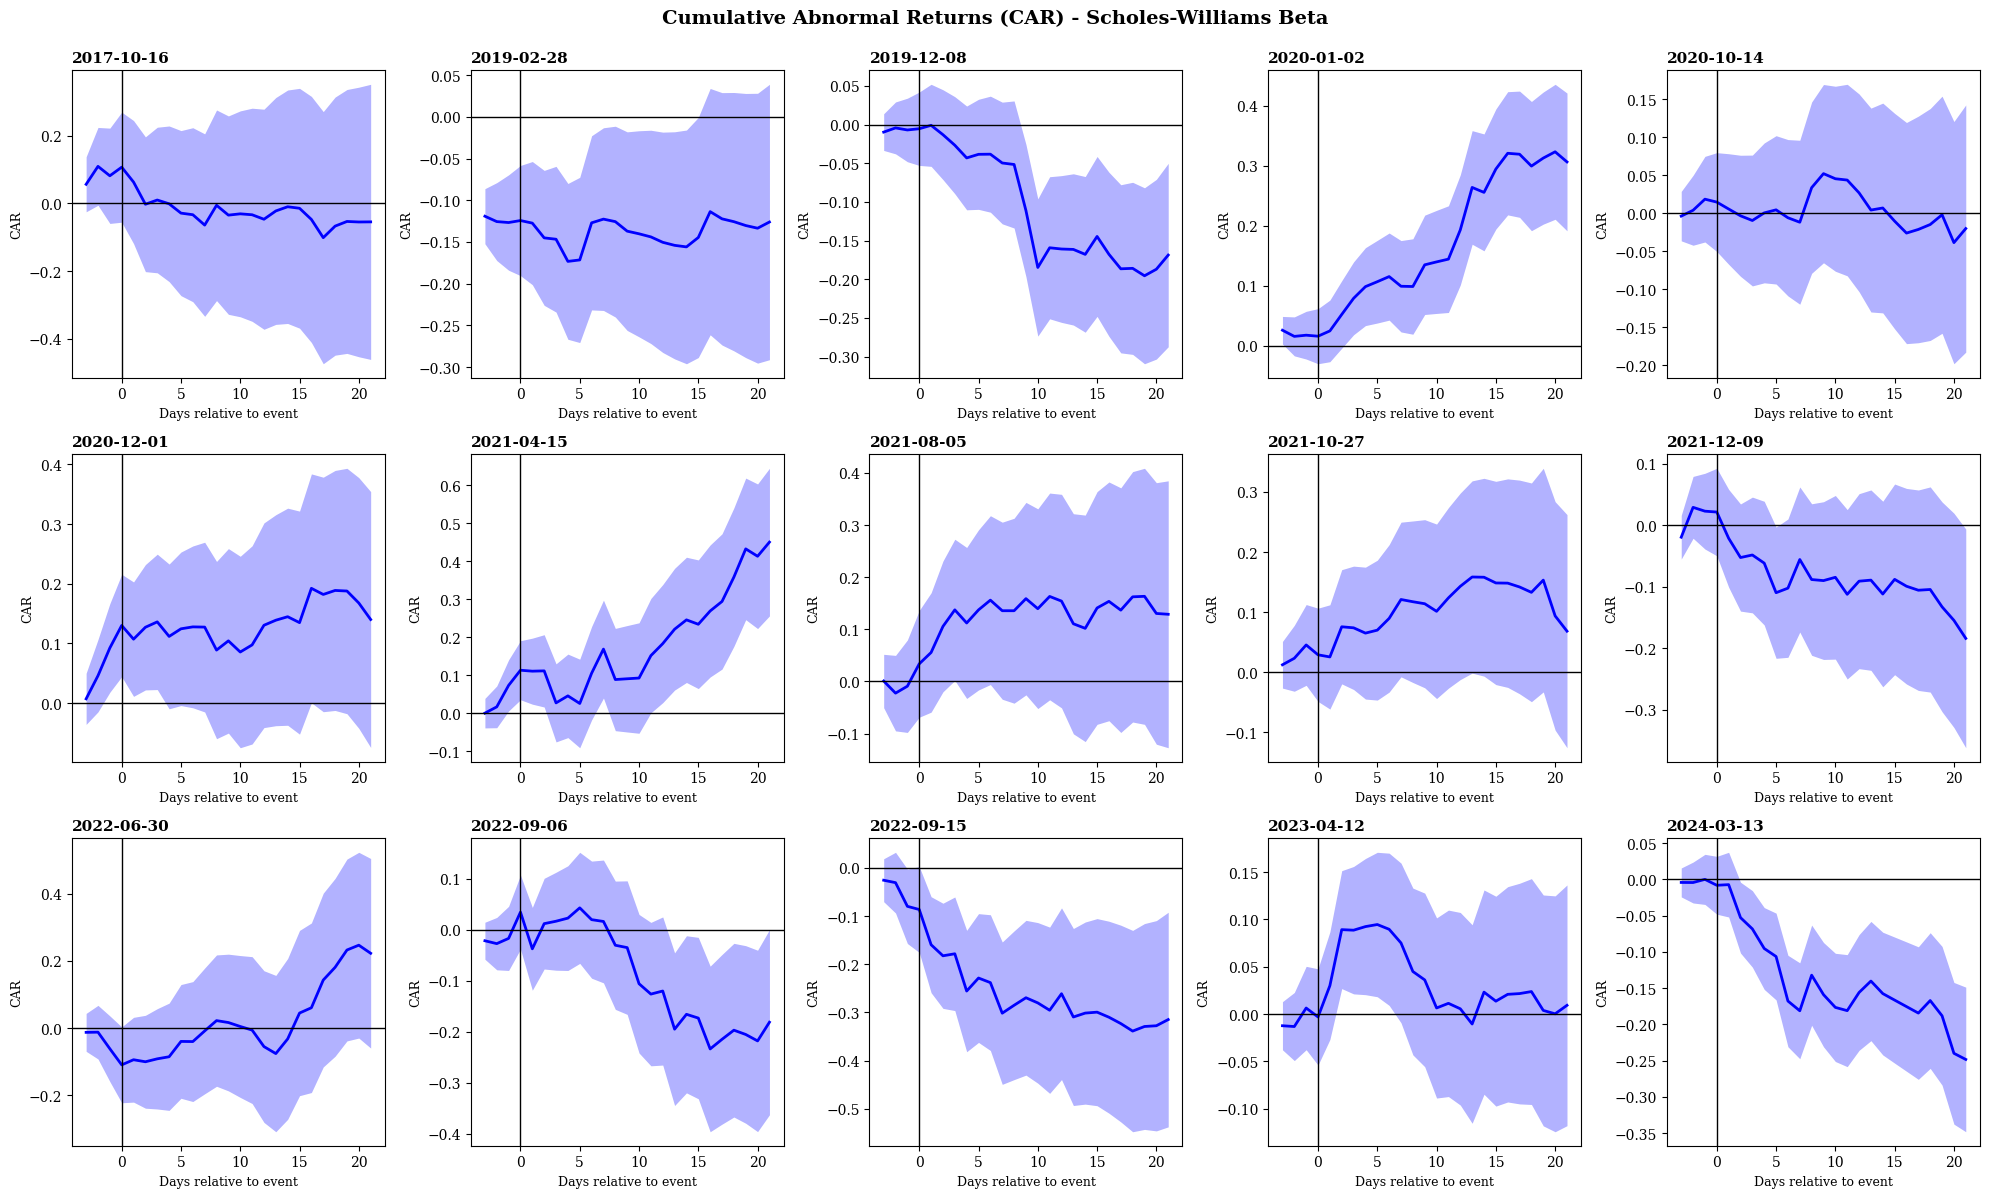

In [15]:
fig = plot_car_grid(
    car_df=eth_cumulative_abnormal_log_returns,
    car_upper_df=eth_car_upper_confidence_bound,
    car_lower_df=eth_car_lower_confidence_bound,
    save_path="car_grid_scholes_williams.png",
)

plt.show()

In [16]:
print("\n" + "="*80)
print("Saving Results to CSV Files")
print("="*80)

# Save event market model results
event_market_model_results.to_csv(
    EVENT_MARKET_MODEL_RESULTS_FILE,
    index=False,
)
print(f"\n✓ Saved: {EVENT_MARKET_MODEL_RESULTS_FILE}")

# Save pre-event abnormal returns
pre_event_abnormal_log_returns.to_csv(
    PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE,
    index=True,
)
print(f"✓ Saved: {PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE}")

# Save ETH event window log returns
eth_event_window_log_returns.to_csv(
    ETH_EVENT_WINDOW_LOG_RETURNS_FILE,
    index=True,
)
print(f"✓ Saved: {ETH_EVENT_WINDOW_LOG_RETURNS_FILE}")

# Save CRIX event window log returns
crix_event_window_log_returns.to_csv(
    CRIX_EVENT_WINDOW_LOG_RETURNS_FILE,
    index=True,
)
print(f"✓ Saved: {CRIX_EVENT_WINDOW_LOG_RETURNS_FILE}")

# Save ETH abnormal log returns
eth_abnormal_log_returns.to_csv(
    ETH_ABNORMAL_LOG_RETURNS_FILE,
    index=True,
)
print(f"✓ Saved: {ETH_ABNORMAL_LOG_RETURNS_FILE}")

print("\n" + "="*80)
print("All results saved successfully!")
print("="*80)

print("\nFiles created:")
print(f"  1. {EVENT_MARKET_MODEL_RESULTS_FILE.name}")
print(f"  2. {PRE_EVENT_ABNORMAL_LOG_RETURNS_FILE.name}")
print(f"  3. {ETH_EVENT_WINDOW_LOG_RETURNS_FILE.name}")
print(f"  4. {CRIX_EVENT_WINDOW_LOG_RETURNS_FILE.name}")
print(f"  5. {ETH_ABNORMAL_LOG_RETURNS_FILE.name}")


Saving Results to CSV Files

✓ Saved: ..\Data\event_market_model_results_scholes_williams.csv
✓ Saved: ..\Data\pre_event_abnormal_log_returns_scholes_williams.csv
✓ Saved: ..\Data\eth_event_window_log_returns.csv
✓ Saved: ..\Data\crix_event_window_log_returns.csv
✓ Saved: ..\Data\eth_abnormal_log_returns_scholes_williams.csv

All results saved successfully!

Files created:
  1. event_market_model_results_scholes_williams.csv
  2. pre_event_abnormal_log_returns_scholes_williams.csv
  3. eth_event_window_log_returns.csv
  4. crix_event_window_log_returns.csv
  5. eth_abnormal_log_returns_scholes_williams.csv
